# HW 11: Clustering

In [2]:
%pylab inline
import warnings

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_boston
from sklearn.preprocessing import StandardScaler

Populating the interactive namespace from numpy and matplotlib


### Importing data

In [3]:
df = pd.read_csv('data/cluster_data.csv')

In [4]:
df.head()

,feature1,feature2,feature3,feature4,feature5,feature6,feature7
0,0.796050,-0.636989,-0.986234,1.687131,0.477556,-0.248949,2.220485
1,0.238882,1.436424,-1.318154,2.154366,0.957094,1.931928,2.314417
2,0.790021,0.131098,-2.282180,1.297790,0.855570,0.429589,1.827104
3,1.836812,-0.349658,-2.426900,1.194719,1.661983,-0.074872,2.425383
4,1.454204,0.560128,-2.204841,1.719233,1.734268,0.955552,2.693549


In [5]:
# multicore implementation
# !pip install MulticoreTSNE

# that's logging for the multicore
# ! pip install wurlitzer
%load_ext wurlitzer

# GPU implementation, seems like outside conda it has to be built from source
# https://github.com/CannyLab/tsne-cuda
# !conda install tsnecuda cuda90 -c cannylab 

In [6]:
# It turns out that sklearn's tsne takes quite some time to run
# So, utilizing GPU

from sklearn.cluster import KMeans
from tsnecuda import TSNE
# from sklearn.manifold import TSNE
# from MulticoreTSNE import MulticoreTSNE as TSNE

# Visualizing using t-SNE
tsne_transform = TSNE(n_components=2,
                      perplexity=500, verbose=1,
                      n_iter=5000, random_seed=42)
tsne_df = tsne_transform.fit_transform(df)

Initializing cuda handles... done.
KNN Computation... done.
Computing Pij matrix... done.
Initializing low dim points... done.
Initializing CUDA memory... done.
[Step 0] Avg. Gradient Norm: 1.40836e-06
[Step 10] Avg. Gradient Norm: 5.54313e-06
[Step 20] Avg. Gradient Norm: 3.88982e-06
[Step 30] Avg. Gradient Norm: 1.35695e-06
[Step 40] Avg. Gradient Norm: 4.28125e-07
[Step 50] Avg. Gradient Norm: 2.28163e-07
[Step 60] Avg. Gradient Norm: 1.56606e-07
[Step 70] Avg. Gradient Norm: 1.24549e-07
[Step 80] Avg. Gradient Norm: 1.19185e-07
[Step 90] Avg. Gradient Norm: 1.37019e-07
[Step 100] Avg. Gradient Norm: 1.78677e-07
[Step 110] Avg. Gradient Norm: 2.50649e-07
[Step 120] Avg. Gradient Norm: 3.68093e-07
[Step 130] Avg. Gradient Norm: 5.59823e-07
[Step 140] Avg. Gradient Norm: 8.78786e-07
[Step 150] Avg. Gradient Norm: 1.42303e-06
[Step 160] Avg. Gradient Norm: 2.37777e-06
[Step 170] Avg. Gradient Norm: 4.10145e-06
[Step 180] Avg. Gradient Norm: 7.3058e-06
[Step 190] Avg. Gradient Norm: 1.3

[Step 1940] Avg. Gradient Norm: 0.0129356
[Step 1950] Avg. Gradient Norm: 0.0129002
[Step 1960] Avg. Gradient Norm: 0.0128607
[Step 1970] Avg. Gradient Norm: 0.012819
[Step 1980] Avg. Gradient Norm: 0.012781
[Step 1990] Avg. Gradient Norm: 0.0127451
[Step 2000] Avg. Gradient Norm: 0.0127099
[Step 2010] Avg. Gradient Norm: 0.0126737
[Step 2020] Avg. Gradient Norm: 0.0126366
[Step 2030] Avg. Gradient Norm: 0.0125949
[Step 2040] Avg. Gradient Norm: 0.0125558
[Step 2050] Avg. Gradient Norm: 0.0125168
[Step 2060] Avg. Gradient Norm: 0.0124729
[Step 2070] Avg. Gradient Norm: 0.0124346
[Step 2080] Avg. Gradient Norm: 0.0123908
[Step 2090] Avg. Gradient Norm: 0.0123478
[Step 2100] Avg. Gradient Norm: 0.0123031
[Step 2110] Avg. Gradient Norm: 0.0122591
[Step 2120] Avg. Gradient Norm: 0.0122125
[Step 2130] Avg. Gradient Norm: 0.012165
[Step 2140] Avg. Gradient Norm: 0.0121111
[Step 2150] Avg. Gradient Norm: 0.0120561
[Step 2160] Avg. Gradient Norm: 0.0120035
[Step 2170] Avg. Gradient Norm: 0.011

[Step 3860] Avg. Gradient Norm: 0.000986213
[Step 3870] Avg. Gradient Norm: 0.00100153
[Step 3880] Avg. Gradient Norm: 0.00100284
[Step 3890] Avg. Gradient Norm: 0.00100968
[Step 3900] Avg. Gradient Norm: 0.00103598
[Step 3910] Avg. Gradient Norm: 0.00100738
[Step 3920] Avg. Gradient Norm: 0.00106281
[Step 3930] Avg. Gradient Norm: 0.00108051
[Step 3940] Avg. Gradient Norm: 0.00109879
[Step 3950] Avg. Gradient Norm: 0.00101133
[Step 3960] Avg. Gradient Norm: 0.00100444
[Step 3970] Avg. Gradient Norm: 0.00100801
[Step 3980] Avg. Gradient Norm: 0.00103175
[Step 3990] Avg. Gradient Norm: 0.00105494
[Step 4000] Avg. Gradient Norm: 0.00107294
[Step 4010] Avg. Gradient Norm: 0.00110052
[Step 4020] Avg. Gradient Norm: 0.00108818
[Step 4030] Avg. Gradient Norm: 0.00109794
[Step 4040] Avg. Gradient Norm: 0.00110567
[Step 4050] Avg. Gradient Norm: 0.00110401
[Step 4060] Avg. Gradient Norm: 0.00110559
[Step 4070] Avg. Gradient Norm: 0.00110908
[Step 4080] Avg. Gradient Norm: 0.00112133
[Step 4090

Text(0.5, 1.0, 't-SNE')

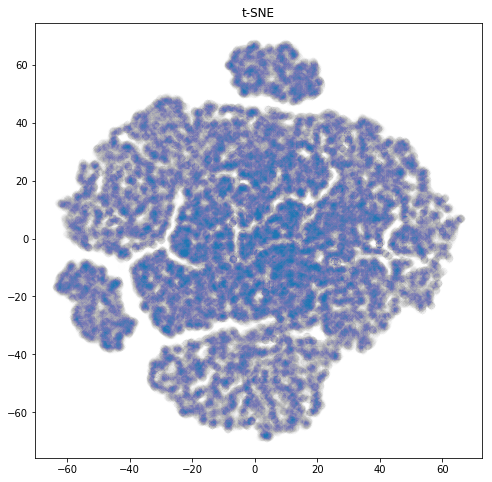

In [7]:
plt.figure(figsize=(8,8))
plt.scatter(tsne_df[:, 0],
            tsne_df[:, 1],
            s=50,
            alpha=0.005)
plt.title('t-SNE')

In [7]:
# !pip install hdbscan

In [8]:
# sampling the data to speed up the process
sample_shape = int(1*tsne_df.shape[0])
sample_data = tsne_df[np.random.choice(tsne_df.shape[0],
                                       sample_shape,
                                       replace=False)]
sample_data.shape

(200000, 2)

In [9]:
from sklearn.cluster import DBSCAN, OPTICS, SpectralClustering, Birch
import hdbscan

dbscan = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=25, core_dist_n_jobs=-1)
dbscan.fit(sample_data)

HDBSCAN(algorithm='best', allow_single_cluster=False, alpha=1.0,
        approx_min_span_tree=True, cluster_selection_method='eom',
        core_dist_n_jobs=-1, gen_min_span_tree=False, leaf_size=40,
        match_reference_implementation=False, memory=Memory(location=None),
        metric='euclidean', min_cluster_size=10, min_samples=25, p=None,
        prediction_data=False)

### Evaluating the amount of data in each cluster

In [10]:
labels = dbscan.labels_.copy()
val_dict = {val: 100*np.sum(labels==val)/labels.shape[0]
            for val in np.unique(labels)}
val_dict

{0: 5.0045, 1: 4.971, 2: 90.0245}

### Plotting everything together

In [11]:
points_df = pd.DataFrame(sample_data)
points_df['label'] = dbscan.labels_
points_df.columns = ['x', 'y', 'label']

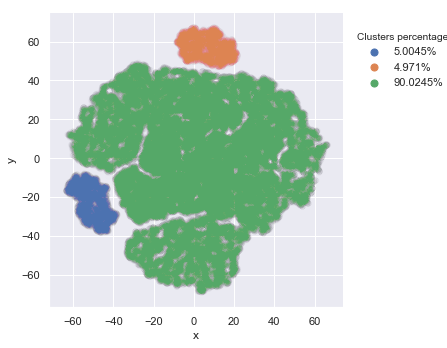

In [12]:
sns.set(rc={'figure.figsize': (11.7, 8.27)})

facet = sns.lmplot(data=points_df, x='x', y='y', hue='label',
                   fit_reg=False, legend=True, legend_out=True,
                   scatter_kws={'alpha': 0.005})

for lh in facet._legend.legendHandles: 
    lh.set_alpha(1)
    lh._sizes = [50]

new_title = 'Clusters percentage'
facet._legend.set_title(new_title)

for t, l in zip(facet._legend.texts, val_dict.values()):
    t.set_text(str(l)+'%')

facet._legend.set_bbox_to_anchor((1.13, .8))

Looks like there are 3-4 clusters overall

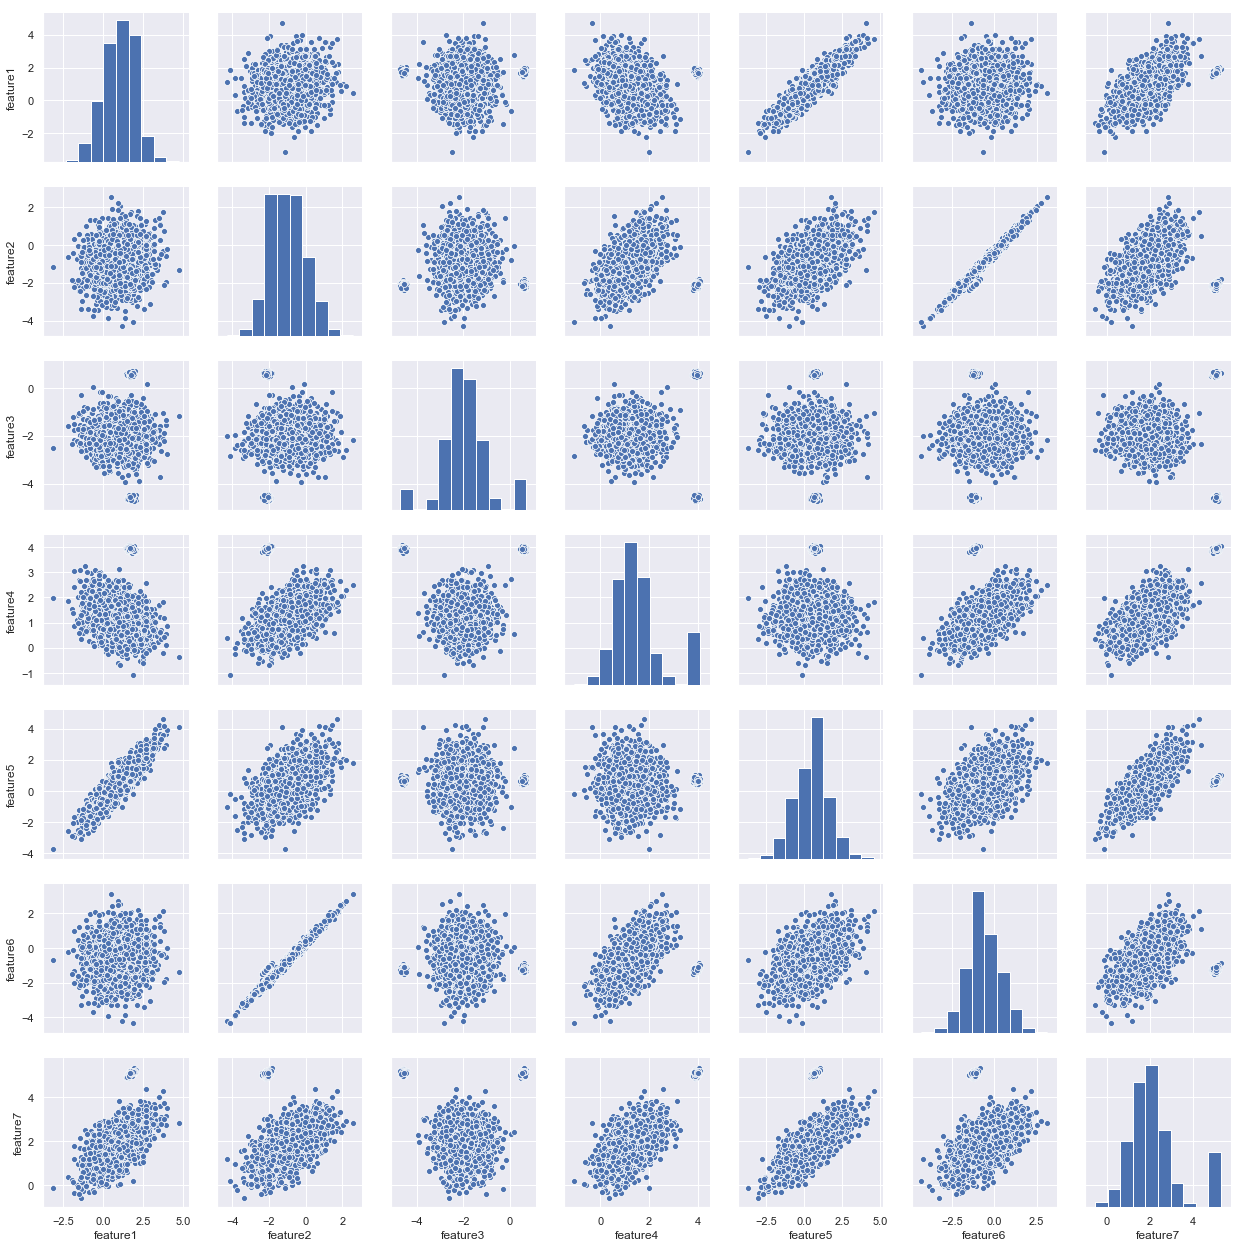

In [13]:
plot_data = df.sample(frac=0.01)
sns.pairplot(plot_data)

Trying kmeans

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(df)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=4, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=42, tol=0.0001, verbose=0)

In [15]:
df['label'] = kmeans.labels_

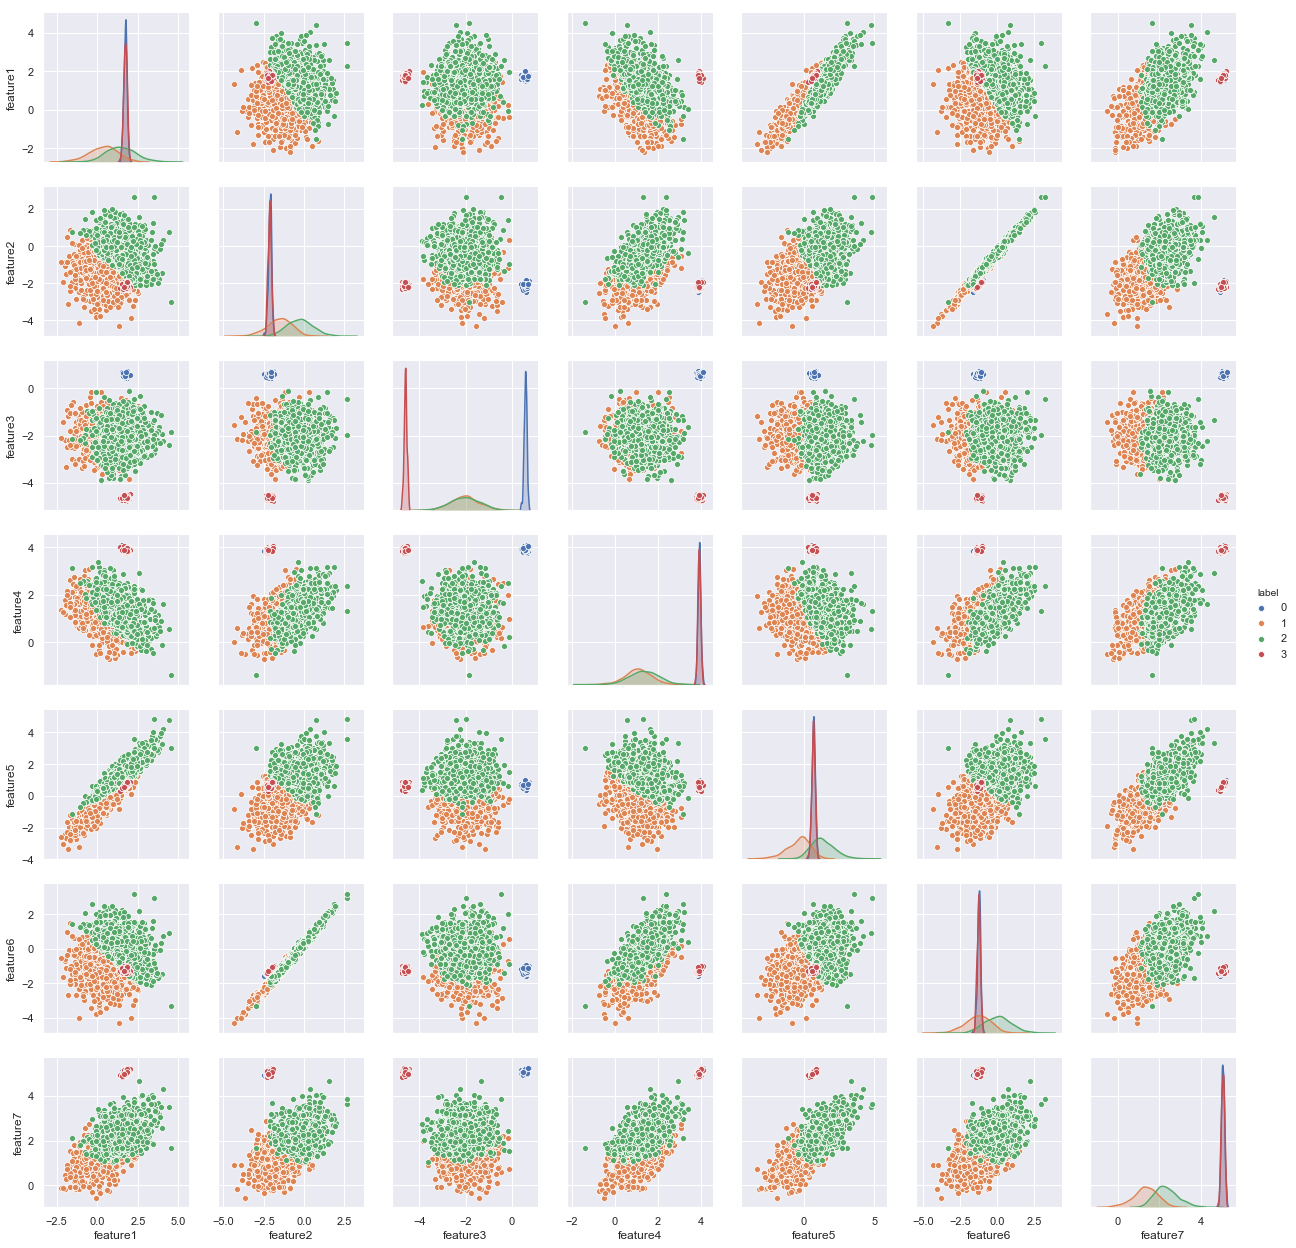

In [16]:
plot_data = df.sample(frac=0.01)
sns.pairplot(plot_data,
             vars=plot_data.columns[plot_data.columns != 'label'],
             hue='label')

Looks like the model is correctly identifying the "small" clusters, but has problems with the large one

In [17]:
df.loc[df['label'] == 2, 'label'] = 1
df.loc[df['label'] == 3, 'label'] = 2

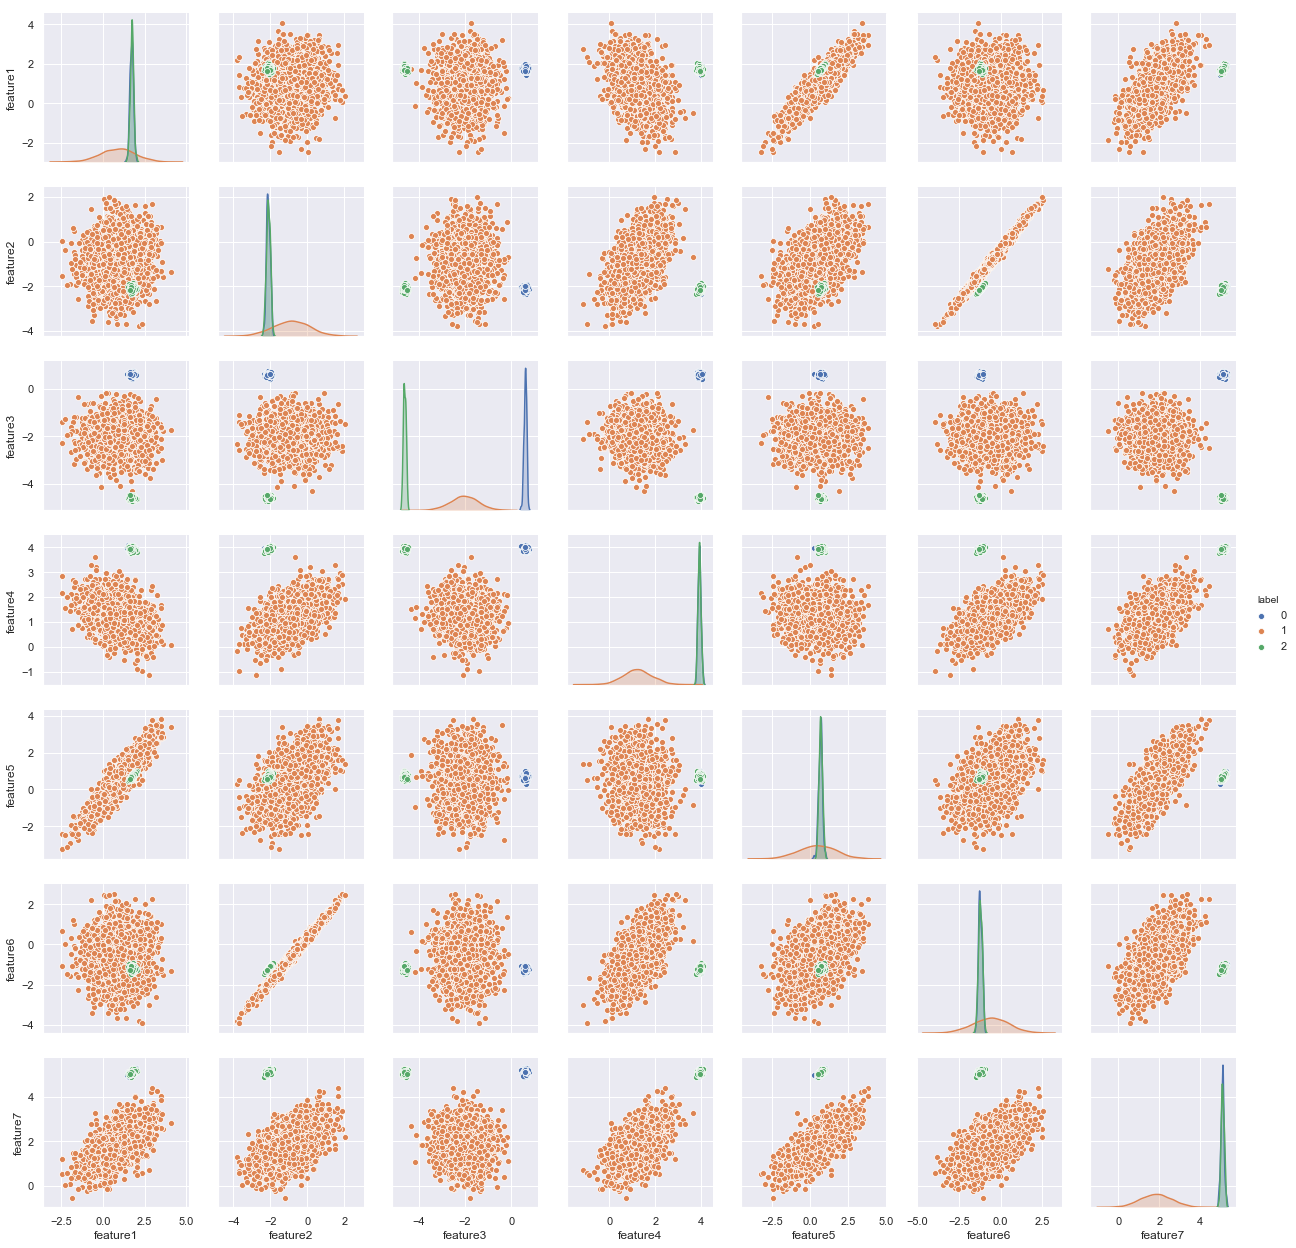

In [18]:
plot_data = df.sample(frac=0.01)
sns.pairplot(plot_data,
             vars=plot_data.columns[plot_data.columns != 'label'],
             hue='label')

Much better now